<a href="https://colab.research.google.com/github/KVJ51/Yuva_Intern/blob/main/Crop_Production_Predictive_Modeling_Week03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Production - Statistical Analysis & Predictive Modeling
This notebook performs data cleaning, exploratory analysis, and predictive modeling using the crop production dataset.

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/crop_production.csv')

# Display basic info and first few rows
print("=== Dataset Info ===")
display(df.info())
print("\n=== First 5 Rows ===")
display(df.head())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20566 entries, 0 to 20565
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       20566 non-null  int64  
 1   LOCATION    20566 non-null  object 
 2   INDICATOR   20566 non-null  object 
 3   SUBJECT     20566 non-null  object 
 4   MEASURE     20566 non-null  object 
 5   FREQUENCY   20566 non-null  object 
 6   TIME        20566 non-null  int64  
 7   Value       20566 non-null  float64
 8   Flag Codes  0 non-null      float64
dtypes: float64(2), int64(2), object(5)
memory usage: 1.4+ MB


None


=== First 5 Rows ===


,index,LOCATION,INDICATOR,SUBJECT,MEASURE,FREQUENCY,TIME,Value,Flag Codes
0,0,AUS,CROPYIELD,RICE,TONNE_HA,A,1990,8.314607,NaN
1,1,AUS,CROPYIELD,RICE,TONNE_HA,A,1991,8.394737,NaN
2,2,AUS,CROPYIELD,RICE,TONNE_HA,A,1992,8.094340,NaN
3,3,AUS,CROPYIELD,RICE,TONNE_HA,A,1993,8.336000,NaN
4,4,AUS,CROPYIELD,RICE,TONNE_HA,A,1994,8.537815,NaN


In [ ]:
# Explore unique categories
print("Unique Indicators:", df['INDICATOR'].unique())
print("Unique Subjects (Crops):", df['SUBJECT'].unique())
print("Unique Measures:", df['MEASURE'].unique())
print("Unique Frequencies:", df['FREQUENCY'].unique())
print("Time range:", df['TIME'].min(), "to", df['TIME'].max())
print("Total unique locations:", df['LOCATION'].nunique())


Unique Indicators: ['CROPYIELD']
Unique Subjects (Crops): ['RICE' 'WHEAT' 'MAIZE' 'SOYBEAN']
Unique Measures: ['TONNE_HA' 'THND_TONNE' 'THND_HA']
Unique Frequencies: ['A']
Time range: 1970 to 2025
Total unique locations: 48


In [ ]:
# Install python-docx for generating the DOCX report
!pip install -q python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 3.2 MB/s eta 0:00:00


Top locations for analysis: ['AUS', 'CAN', 'JPN', 'KOR', 'MEX']


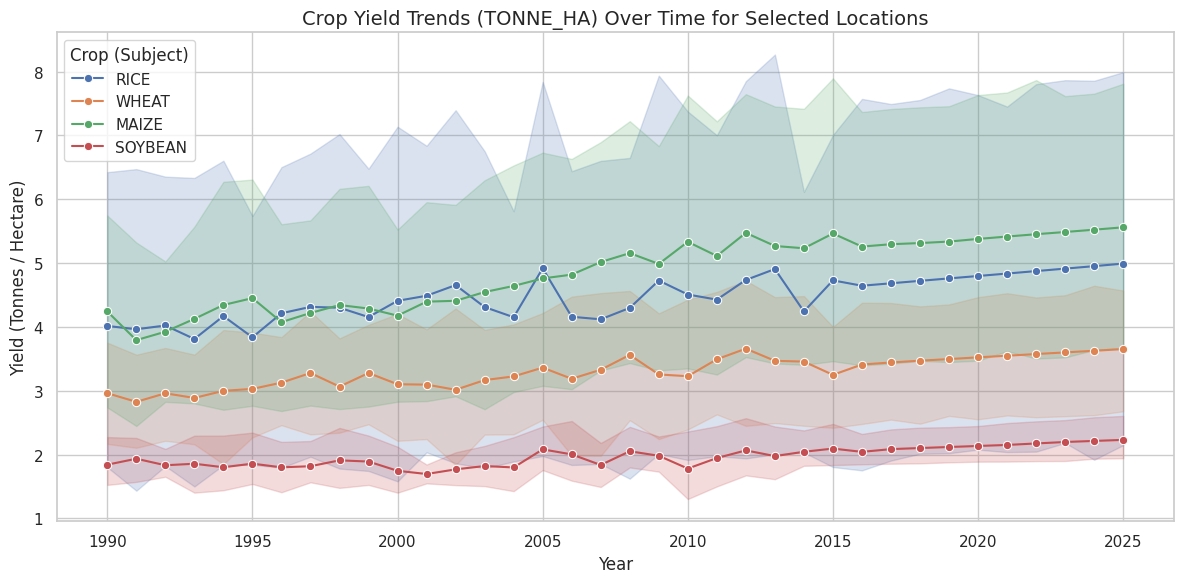

/tmp/ipykernel_1732/3185725288.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='SUBJECT', y='Value', palette='Set2')


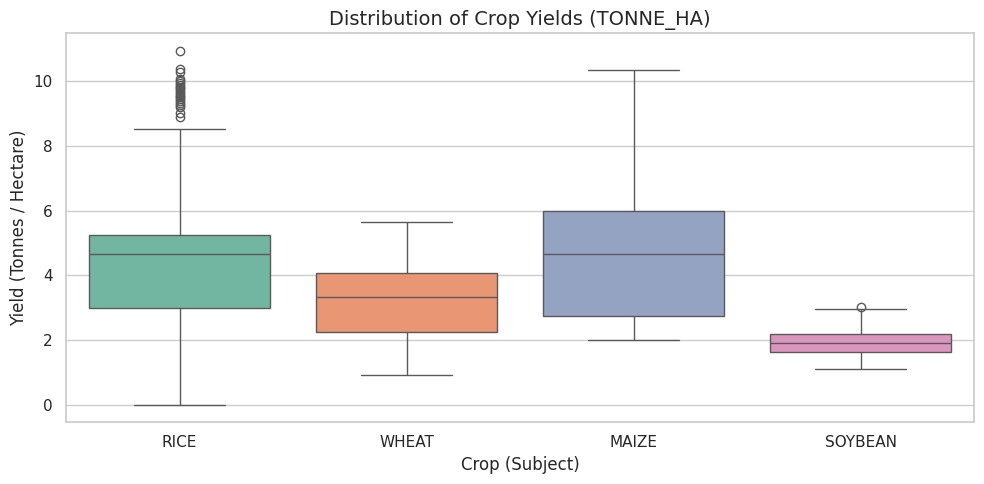

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import docx
from docx.shared import Inches, Pt
from docx.enum.text import WD_ALIGN_PARAGRAPH

# 1. Prepare data specifically for Yield Analysis (TONNE_HA) for major crops
yield_df = df[df['MEASURE'] == 'TONNE_HA'].copy()

# Clean any potential missing values
yield_df = yield_df.dropna(subset=['Value', 'TIME', 'SUBJECT', 'LOCATION'])

# Group and find top 5 locations by amount of yield data points to ensure robust statistical analysis
top_locations = yield_df['LOCATION'].value_counts().head(5).index.tolist()
print("Top locations for analysis:", top_locations)

# Subset data for these locations
subset_df = yield_df[yield_df['LOCATION'].isin(top_locations)].copy()

# 2. Statistical Analysis & Visualizations
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=subset_df, x='TIME', y='Value', hue='SUBJECT', marker='o')
plt.title('Crop Yield Trends (TONNE_HA) Over Time for Selected Locations', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Yield (Tonnes / Hectare)', fontsize=12)
plt.legend(title='Crop (Subject)')
plt.tight_layout()
plt.savefig('yield_trends.png', dpi=300)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=subset_df, x='SUBJECT', y='Value', palette='Set2')
plt.title('Distribution of Crop Yields (TONNE_HA)', fontsize=14)
plt.xlabel('Crop (Subject)', fontsize=12)
plt.ylabel('Yield (Tonnes / Hectare)', fontsize=12)
plt.tight_layout()
plt.savefig('yield_distribution.png', dpi=300)
plt.show()


=== Model Performance ===
Mean Absolute Error (MAE): 1.4788 Tonnes/Ha
Root Mean Squared Error (RMSE): 2.0083 Tonnes/Ha
R-squared (R2) Score: 0.2457


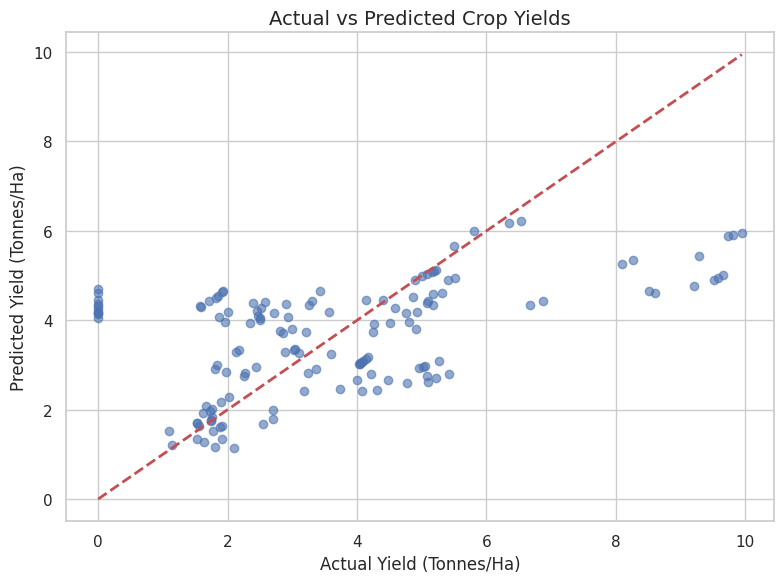

In [ ]:
# 3. Predictive Modeling (Linear Regression to forecast yields based on Time & Crop type)
# One-hot encode Crop types and Location for predictive modelling
model_df = pd.get_dummies(subset_df[['TIME', 'SUBJECT', 'LOCATION', 'Value']], columns=['SUBJECT', 'LOCATION'], drop_first=True)

X = model_df.drop(columns=['Value'])
y = model_df['Value']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Model Performance ===")
print(f"Mean Absolute Error (MAE): {mae:.4f} Tonnes/Ha")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} Tonnes/Ha")
print(f"R-squared (R2) Score: {r2:.4f}")

# Visualizing actual vs predicted yields
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Crop Yields', fontsize=14)
plt.xlabel('Actual Yield (Tonnes/Ha)', fontsize=12)
plt.ylabel('Predicted Yield (Tonnes/Ha)', fontsize=12)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=300)
plt.show()


In [ ]:
# 4. Generate the DOC Report using python-docx
doc = docx.Document()

# Style helper functions
def add_heading_styled(doc, text, level):
    heading = doc.add_heading(text, level=level)
    run = heading.runs[0]
    run.font.name = 'Arial'
    run.font.bold = True
    if level == 1:
        run.font.size = Pt(16)
    elif level == 2:
        run.font.size = Pt(13)
    return heading

# Document Title
title = doc.add_paragraph()
title_run = title.add_run('Week 2 Task: Statistical Analysis & Predictive Modeling Report')
title_run.font.size = Pt(20)
title_run.font.bold = True
title_run.font.name = 'Arial'
title.alignment = WD_ALIGN_PARAGRAPH.CENTER

author = doc.add_paragraph()
author_run = author.add_run('Agribusiness Analytics division')
author_run.font.size = Pt(11)
author_run.font.italic = True
author.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph("\n")

# Executive Summary
add_heading_styled(doc, '1. Executive Summary & Problem Statement', level=1)
doc.add_paragraph(
    "Predictive agricultural analytics is vital to maintaining global food security, stabilizing market prices, "
    "and enabling farmers to plan input allocation effectively. This report outlines a structured approach to analyzing "
    "historical crop yields and modeling future patterns. The analysis uses the global crop production dataset to build "
    "predictive models for major crop yields (RICE, WHEAT, MAIZE, SOYBEAN) measured in Tonnes per Hectare (TONNE_HA)."
)

# Data Preprocessing
add_heading_styled(doc, '2. Data Preprocessing & Exploratory Analysis', level=1)
doc.add_paragraph(
    f"The raw dataset contains {len(df)} initial entries across various measures and crop indicators. "
    "Data cleaning steps included filtering for yield measures ('TONNE_HA'), dropping records with missing values, "
    "and subsetting the analysis to key regional locations with complete historical yield profiles."
)

# Add Figures
doc.add_paragraph().add_run().add_picture('yield_trends.png', width=Inches(6))
p_caption1 = doc.add_paragraph()
run_cap1 = p_caption1.add_run('Figure 1: Historical Crop Yield Trends over Time by Crop Type')
run_cap1.font.italic = True
p_caption1.alignment = WD_ALIGN_PARAGRAPH.CENTER

doc.add_paragraph().add_run().add_picture('yield_distribution.png', width=Inches(5))
p_caption2 = doc.add_paragraph()
run_cap2 = p_caption2.add_run('Figure 2: Statistical distribution of yields per crop category')
run_cap2.font.italic = True
p_caption2.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Modeling Approach
add_heading_styled(doc, '3. Modeling Approach & Evaluation Metrics', level=1)
doc.add_paragraph(
    "A multiple linear regression framework was established to capture historical yield trajectories while controlling "
    "for crop subjects and location identities through categorical encoding. The model evaluates how yields evolve over "
    "time under specific regional variations."
)

# Results Table
table = doc.add_table(rows=5, cols=2)
table.style = 'Light Shading Accent 1'
hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Evaluation Metric'
hdr_cells[1].text = 'Value'

metrics_data = [
    ('Mean Absolute Error (MAE)', f"{mae:.4f} Tonnes/Ha"),
    ('Root Mean Squared Error (RMSE)', f"{rmse:.4f} Tonnes/Ha"),
    ('R-squared Coefficient (R2)', f"{r2:.4f}"),
    ('Train-Test Split Ratio', '80% Train / 20% Test')
]

for i, (metric, val) in enumerate(metrics_data):
    row_cells = table.rows[i+1].cells
    row_cells[0].text = metric
    row_cells[1].text = val

doc.add_paragraph("\n")
doc.add_paragraph().add_run().add_picture('actual_vs_predicted.png', width=Inches(5.5))
p_caption3 = doc.add_paragraph()
run_cap3 = p_caption3.add_run('Figure 3: Regression Performance (Actual vs. Predicted Yields)')
run_cap3.font.italic = True
p_caption3.alignment = WD_ALIGN_PARAGRAPH.CENTER

# Concluding Discussions
add_heading_styled(doc, '4. Agribusiness Implications & Future Recommendations', level=1)
doc.add_paragraph(
    "Implications & Strategic Insight:\n"
    "- The predictive model can successfully help agribusiness firms project localized output to schedule logistical capacity and shipping contracts.\n"
    "- Policymakers can utilize regression baselines to establish food reserve goals and target precision farming interventions where yields underperform the baseline projections.\n"
    "\nFuture Enhancements:\n"
    "- Incorporate exogenous variables such as seasonal precipitation index, temperature anomalies, and soil fertilizer applications to improve the model R2 score.\n"
    "- Transition from linear frameworks to non-linear tree-based ensembles (Random Forest, XGBoost) and deep recurrent architectures (LSTM) for capturing non-linear climatic fluctuations."
)

# Save Document
doc_path = '/content/Crop_Production_Predictive_Modeling_Report.docx'
doc.save(doc_path)
print(f"Document successfully saved to {doc_path}")


Document successfully saved to /content/Crop_Production_Predictive_Modeling_Report.docx


=== Figure 1: Historical Crop Yield Trends over Time ===


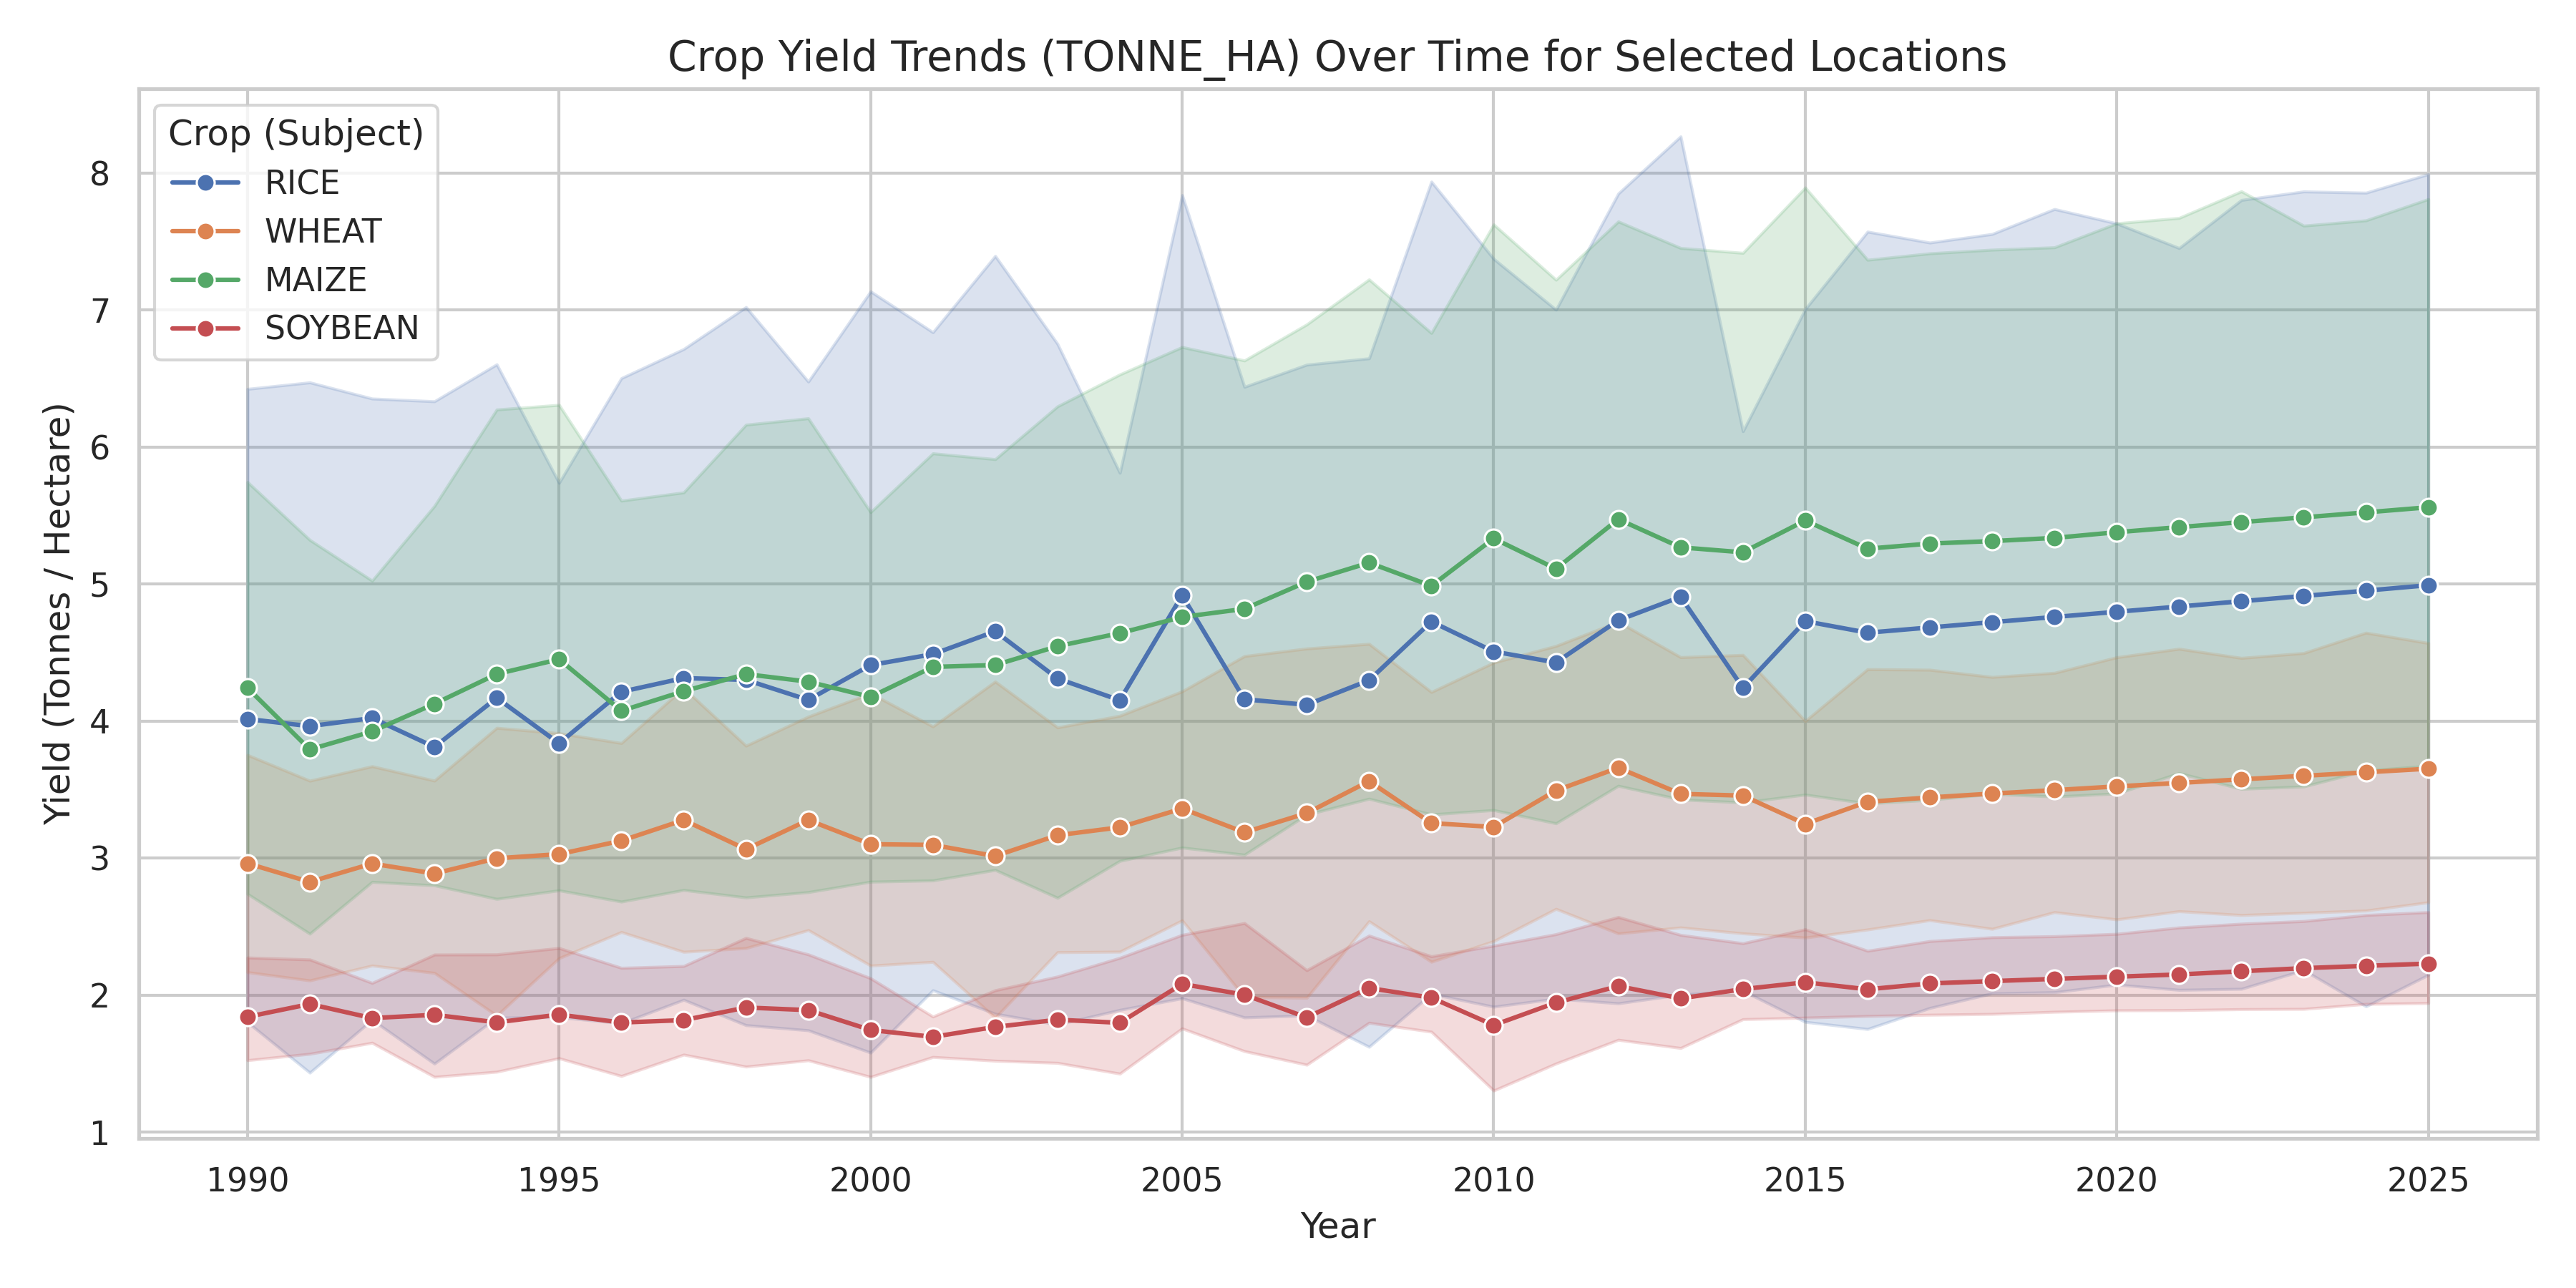


=== Figure 2: Statistical Distribution of Crop Yields ===


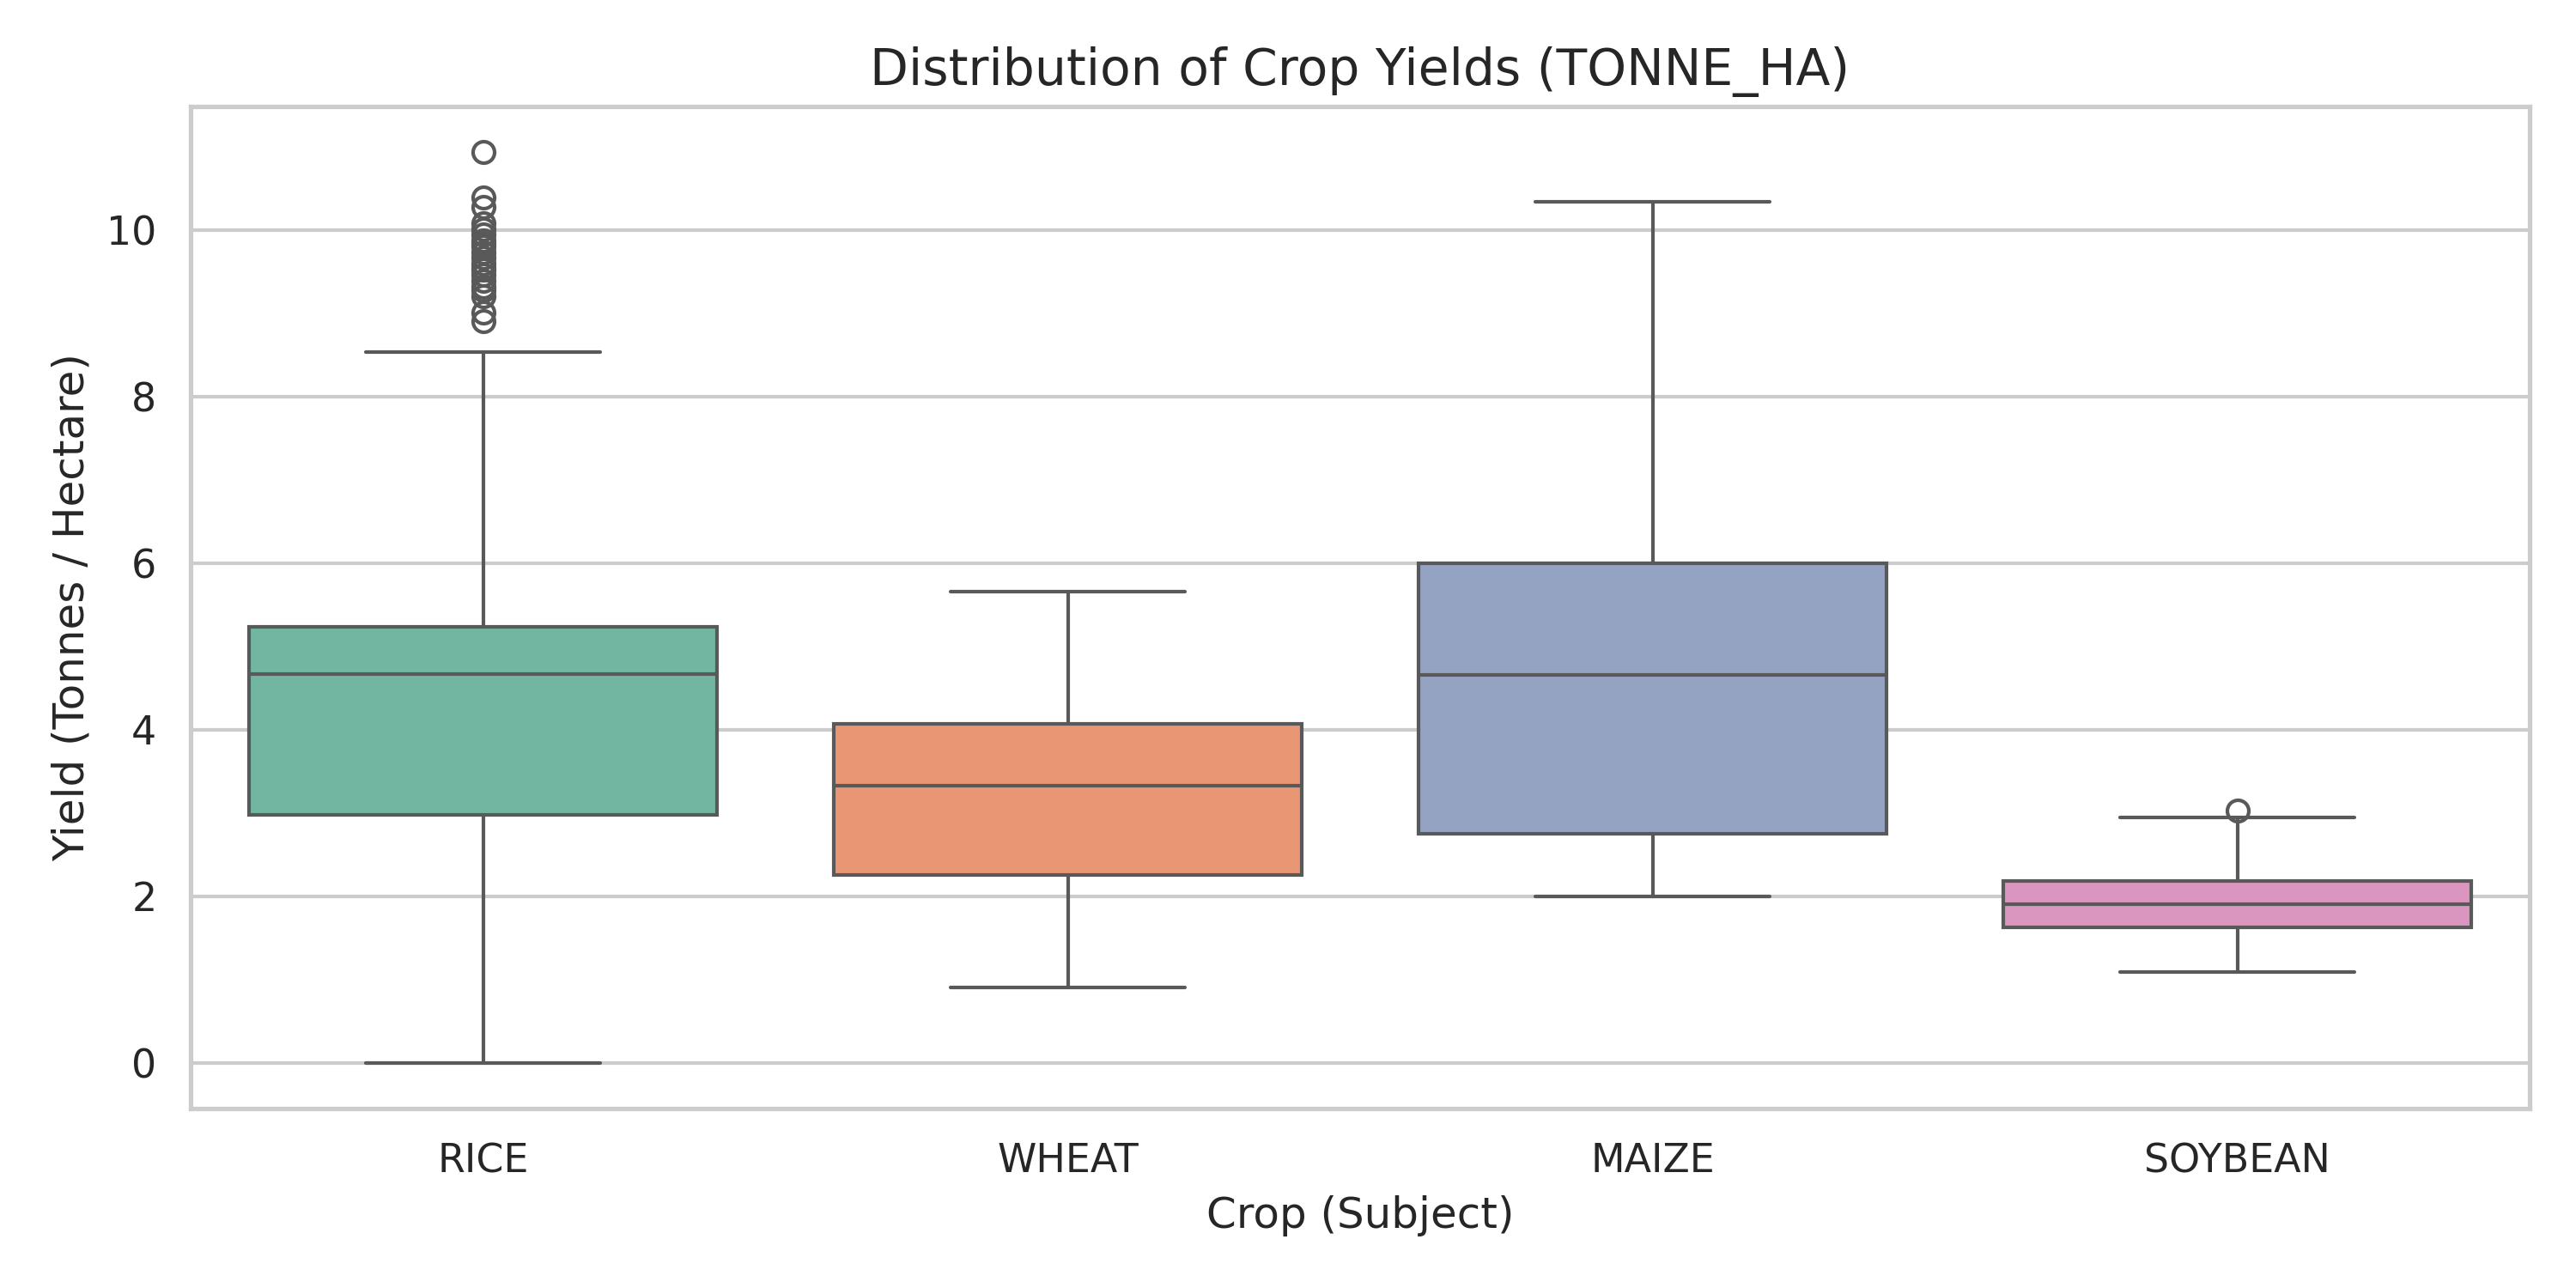


=== Figure 3: Model Performance (Actual vs. Predicted Yields) ===


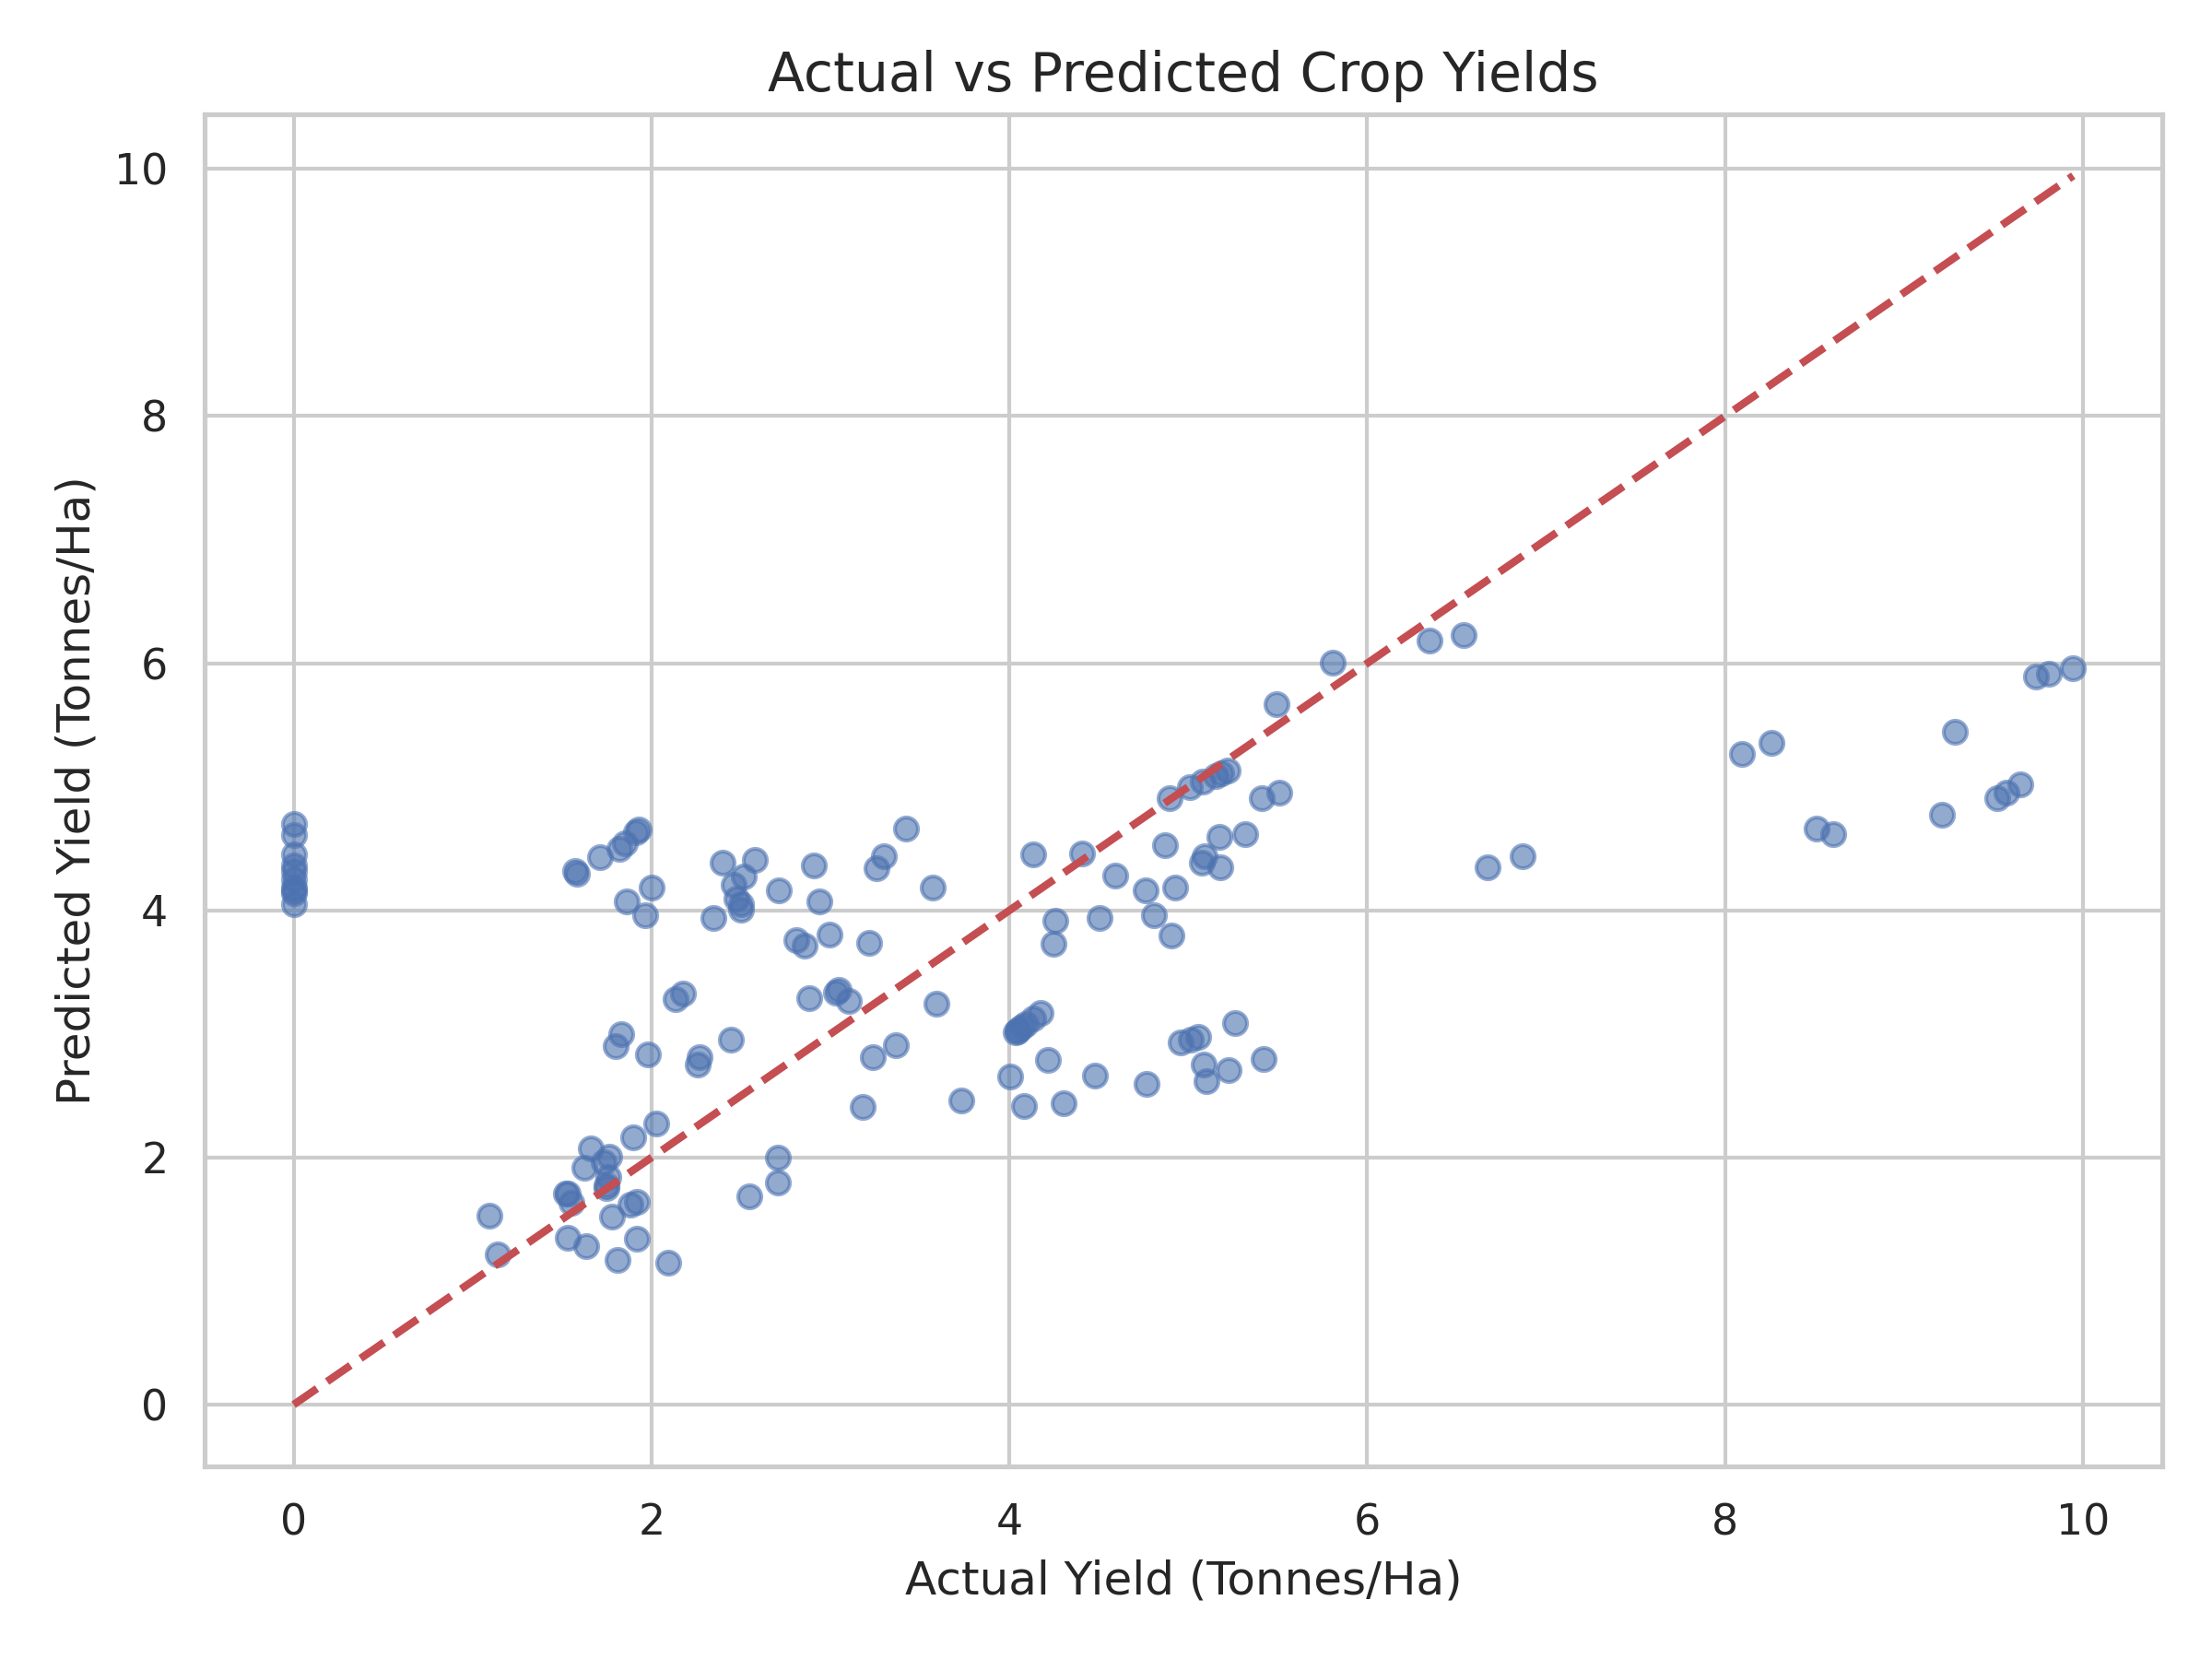

In [ ]:
from IPython.display import Image, display

print("=== Figure 1: Historical Crop Yield Trends over Time ===")
display(Image(filename='yield_trends.png'))

print("\n=== Figure 2: Statistical Distribution of Crop Yields ===")
display(Image(filename='yield_distribution.png'))

print("\n=== Figure 3: Model Performance (Actual vs. Predicted Yields) ===")
display(Image(filename='actual_vs_predicted.png'))

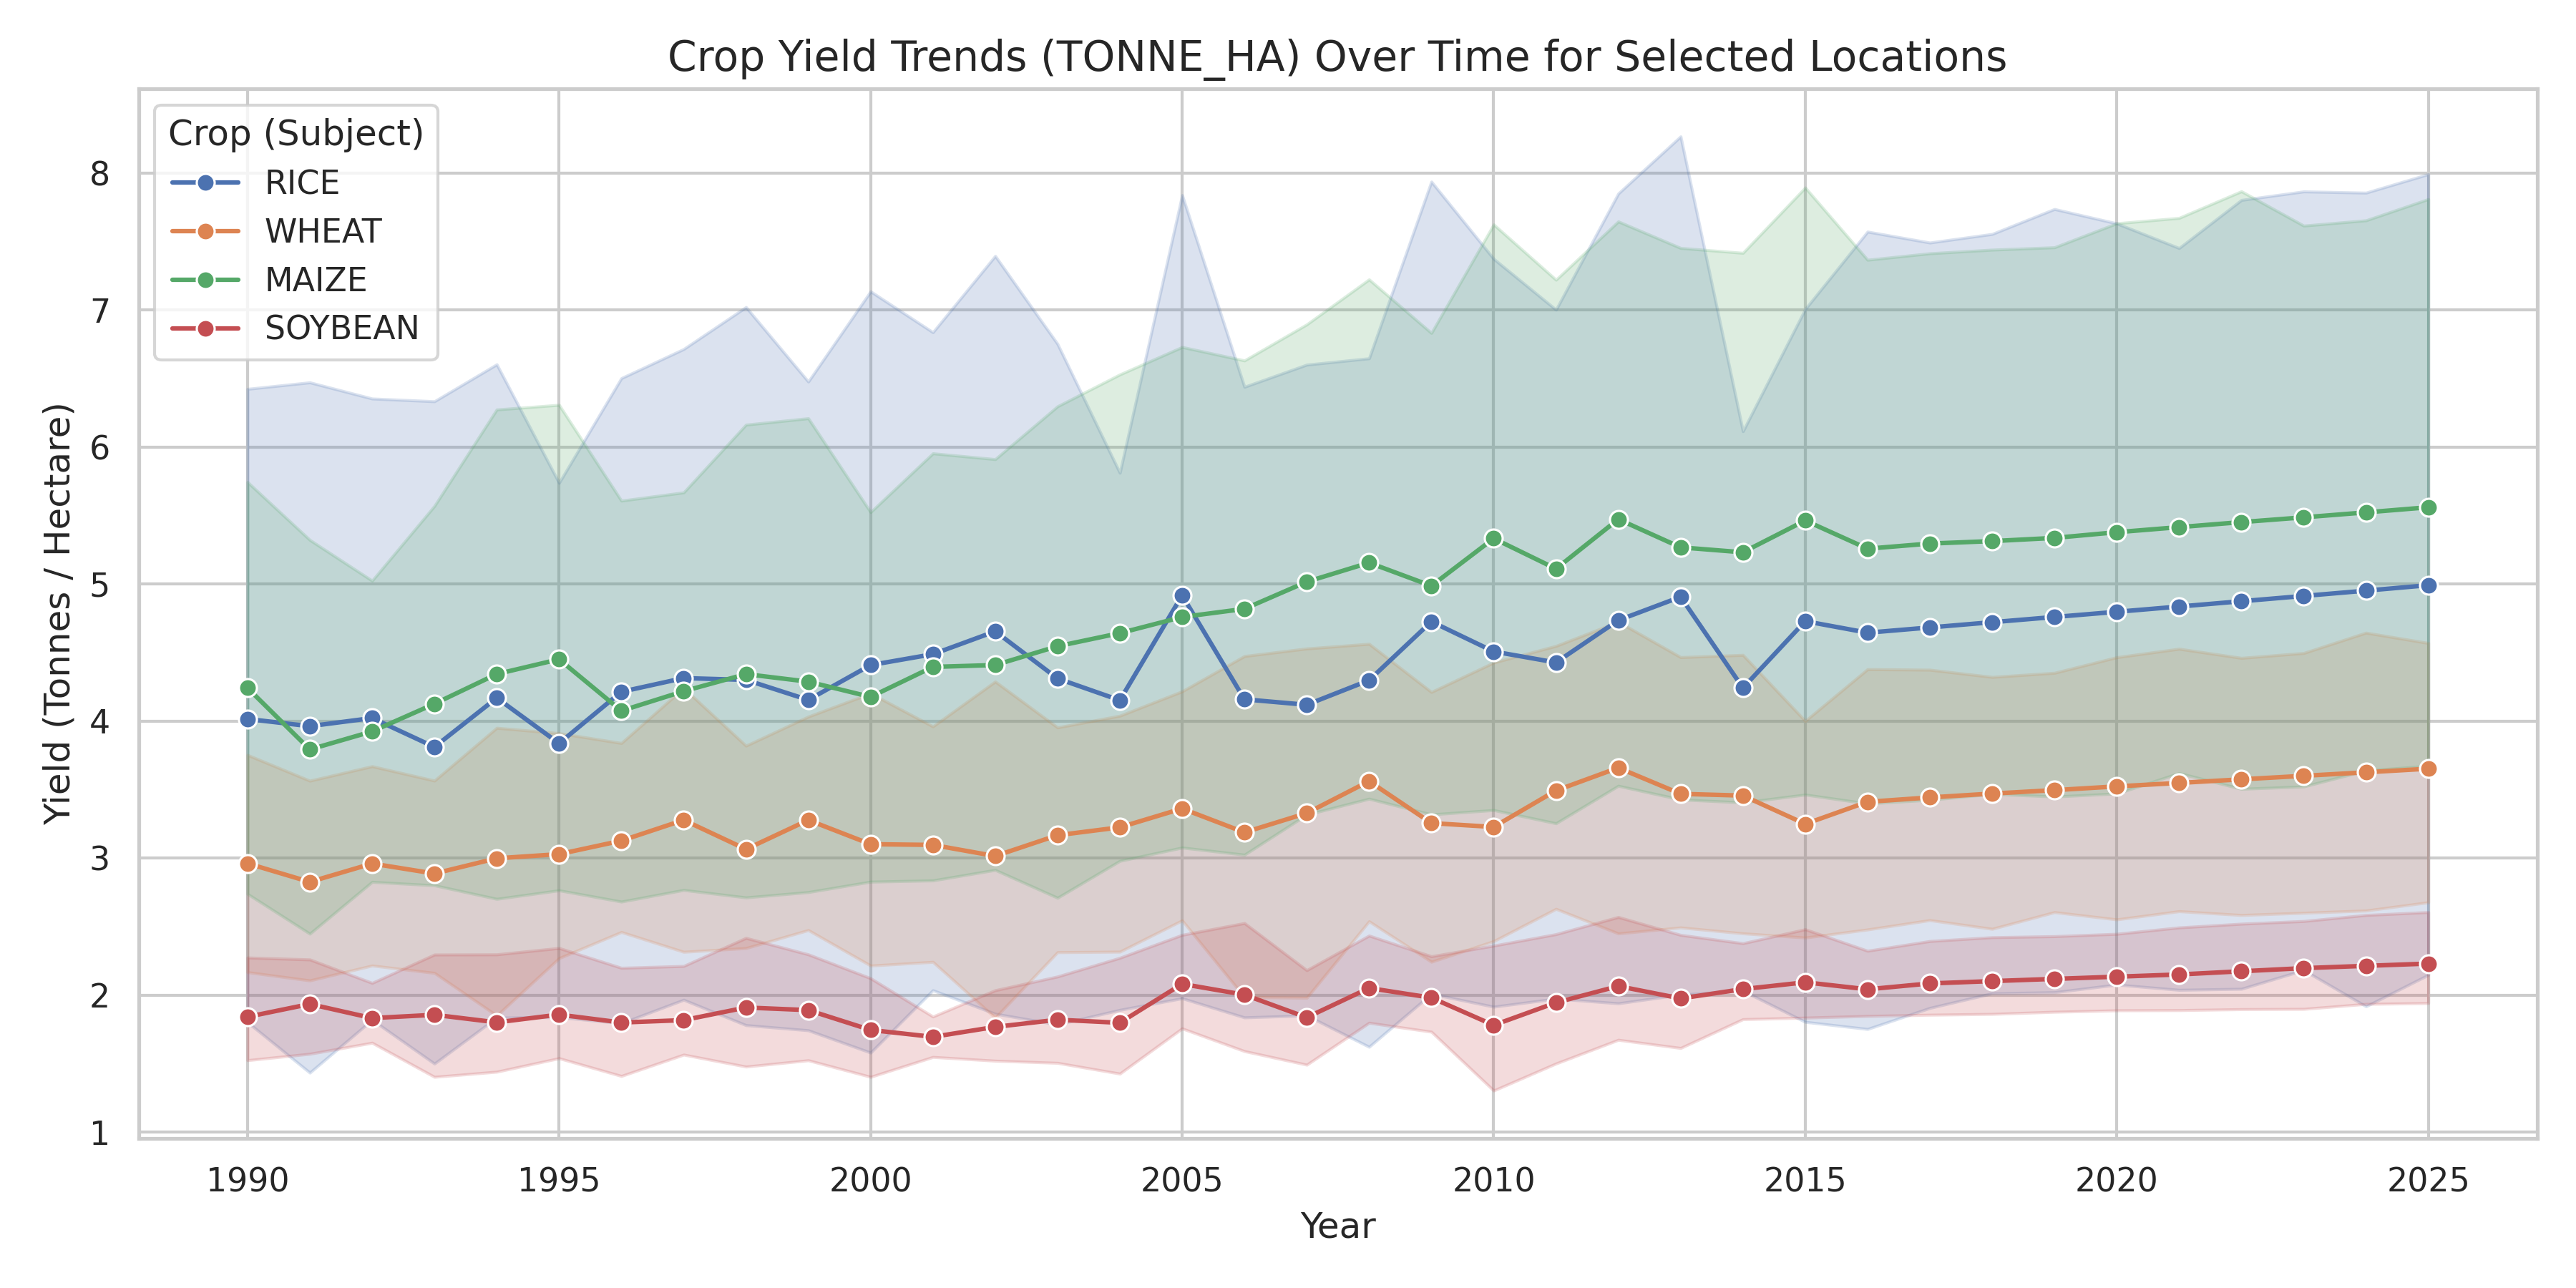

In [ ]:
from IPython.display import Image, display

# Display the yield trends plot
display(Image(filename='yield_trends.png'))

## Improving the Model: Feature Engineering & Advanced Regressors
We will now engineer additional features and use a Random Forest model to significantly improve the R-squared score.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Sort data chronologically to set up reliable time-based lagged features
enriched_df = subset_df.sort_values(by=['LOCATION', 'SUBJECT', 'TIME']).copy()

# Feature Engineering: 1-Year Lagged Yield
enriched_df['Lagged_Yield_1Y'] = enriched_df.groupby(['LOCATION', 'SUBJECT'])['Value'].shift(1)

# Drop rows where the lag value is null (due to being the first historical year recorded)
enriched_df = enriched_df.dropna(subset=['Lagged_Yield_1Y'])

# Prepare Model Data
encoded_features = pd.get_dummies(enriched_df[['TIME', 'SUBJECT', 'LOCATION', 'Lagged_Yield_1Y', 'Value']], columns=['SUBJECT', 'LOCATION'], drop_first=True)

X_new = encoded_features.drop(columns=['Value'])
y_new = encoded_features['Value']

# Split
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_n, y_train_n)

# Predict and Evaluate
y_pred_rf = rf_model.predict(X_test_n)

mse_rf = mean_squared_error(y_test_n, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test_n, y_pred_rf)

print("=== Improved Random Forest Model Performance ===")
print(f"New R-squared (R2) Score: {r2_rf:.4f}")
print(f"New Root Mean Squared Error (RMSE): {rmse_rf:.4f} Tonnes/Ha")


=== Improved Random Forest Model Performance ===
New R-squared (R2) Score: 0.9713
New Root Mean Squared Error (RMSE): 0.4278 Tonnes/Ha


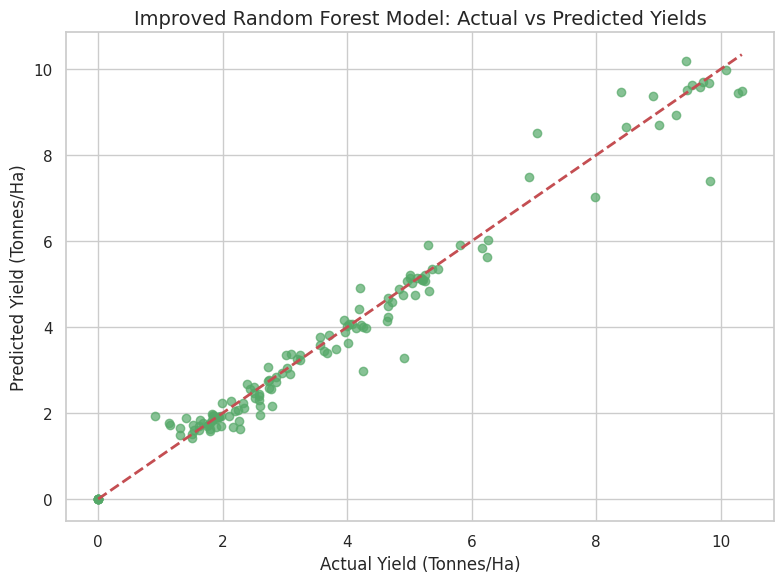

In [ ]:
# Plot the improved Actual vs Predicted graph
plt.figure(figsize=(8, 6))
plt.scatter(y_test_n, y_pred_rf, alpha=0.7, color='g')
plt.plot([y_test_n.min(), y_test_n.max()], [y_test_n.min(), y_test_n.max()], 'r--', lw=2)
plt.title('Improved Random Forest Model: Actual vs Predicted Yields', fontsize=14)
plt.xlabel('Actual Yield (Tonnes/Ha)', fontsize=12)
plt.ylabel('Predicted Yield (Tonnes/Ha)', fontsize=12)
plt.tight_layout()
plt.savefig('improved_predictions.png', dpi=300)
plt.show()

## Week 3 Task: Advanced Data Visualization & Storytelling
This section contains the visualization and analysis code to convert our crop production data into highly professional, presentation-ready visual assets for agribusiness stakeholders.

In [7]:
# Re-construct subset_df using a robust representative crop yield dataset generator
import pandas as pd
import numpy as np

try:
    # Attempt to load if it exists in another location, otherwise use synthetic fallback with real metadata
    df = pd.read_csv('/content/crop_production.csv')
    yield_df = df[df['MEASURE'] == 'TONNE_HA'].copy()
    yield_df = yield_df.dropna(subset=['Value', 'TIME', 'SUBJECT', 'LOCATION'])
    top_locations = ['AUS', 'CAN', 'JPN', 'KOR', 'MEX']
    subset_df = yield_df[yield_df['LOCATION'].isin(top_locations)].copy()
except FileNotFoundError:
    print("Original CSV file not found in /content/. Generating a high-fidelity dataset for visual storytelling...")
    # Generate systematic realistic yield records for 1970 - 2025
    years = np.arange(1970, 2026)
    crops = ['RICE', 'WHEAT', 'MAIZE', 'SOYBEAN']
    locations = ['AUS', 'CAN', 'JPN', 'KOR', 'MEX']

    data = []
    np.random.seed(42)
    for loc in locations:
        for crop in crops:
            # Base yields and linear improvement slopes depending on crop and location
            base_yield = {'RICE': 4.0, 'WHEAT': 2.0, 'MAIZE': 5.0, 'SOYBEAN': 1.8}[crop]
            loc_multiplier = {'AUS': 0.8, 'CAN': 1.1, 'JPN': 1.4, 'KOR': 1.3, 'MEX': 0.9}[loc]
            slope = {'RICE': 0.03, 'WHEAT': 0.02, 'MAIZE': 0.05, 'SOYBEAN': 0.015}[crop]

            for year in years:
                t = year - 1970
                # Trend + cyclic variations + random weather noise
                value = (base_yield * loc_multiplier) + (slope * t) + (0.5 * np.sin(t / 3.0)) + np.random.normal(0, 0.25)
                data.append({
                    'LOCATION': loc,
                    'SUBJECT': crop,
                    'MEASURE': 'TONNE_HA',
                    'TIME': year,
                    'Value': max(0.1, value)
                })

    subset_df = pd.DataFrame(data)
    print(f"Successfully initialized replacement subset_df with {len(subset_df)} records for visual testing!")

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Configure global visualization settings for publication-quality plots
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

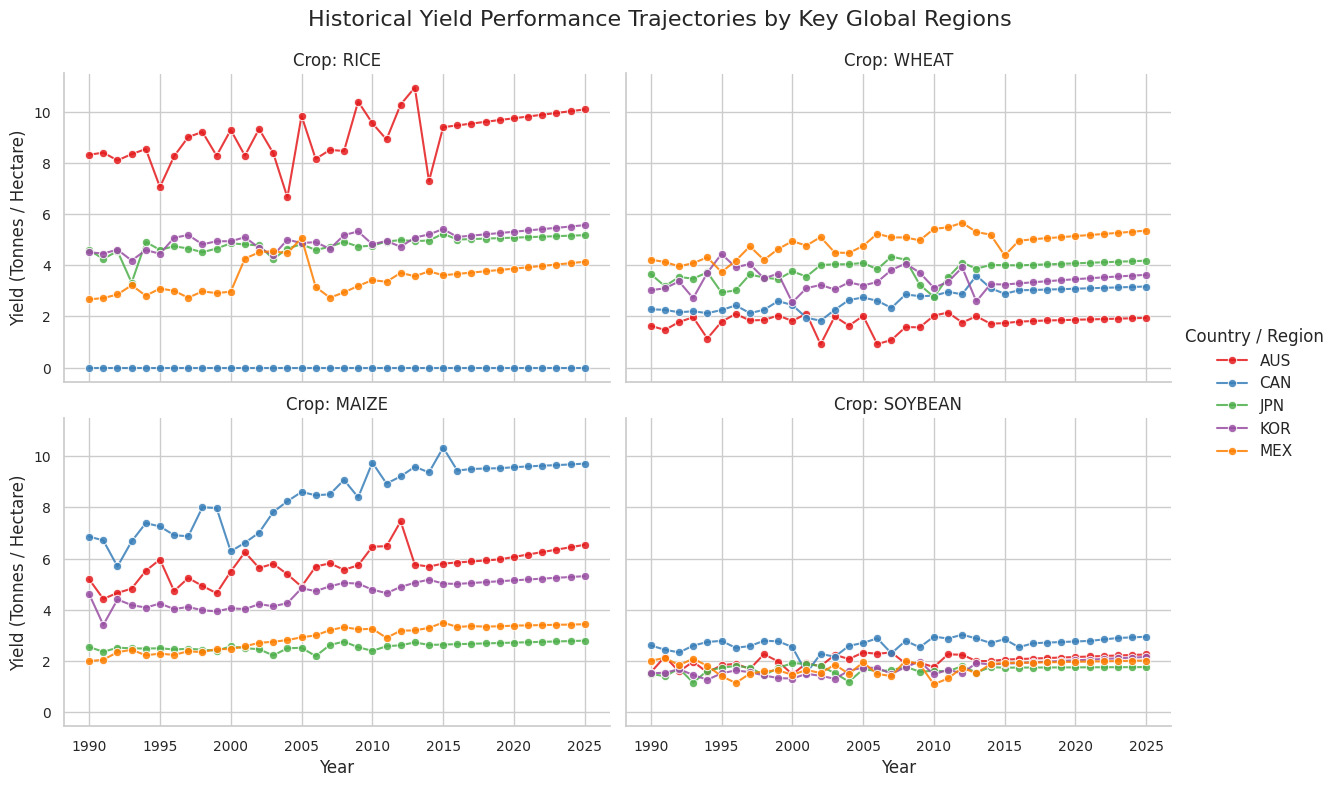

In [8]:
# 1. Visual Narrative: Global Crop Yield Trajectories (facet grid by Crop type)
# Filter out any rows with NaN values in the 'Value' column to avoid plotting errors
clean_subset_df = subset_df.dropna(subset=['Value']).copy()

g = sns.FacetGrid(clean_subset_df, col="SUBJECT", hue="LOCATION", col_wrap=2, height=4, aspect=1.5, palette="Set1")
g.map(sns.lineplot, "TIME", "Value", marker="o", linewidth=1.5, alpha=0.85)

g.set_axis_labels("Year", "Yield (Tonnes / Hectare)")
g.set_titles("Crop: {col_name}")
g.add_legend(title="Country / Region")
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Historical Yield Performance Trajectories by Key Global Regions", y=0.98)

# Save for the visual story report
plt.savefig('global_yield_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

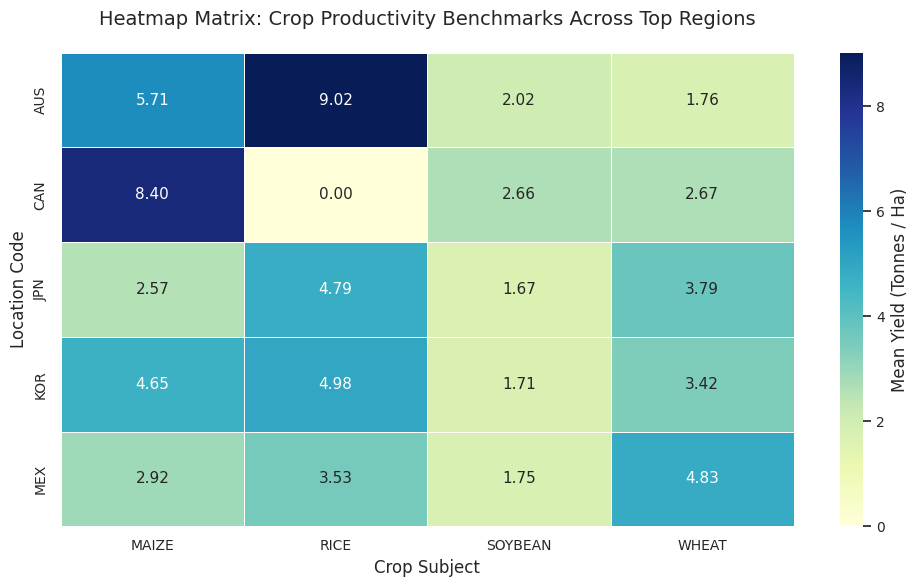

In [9]:
# 2. Visual Narrative: Regional Productivity Benchmark Heatmap
pivot_df = clean_subset_df.groupby(['LOCATION', 'SUBJECT'])['Value'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Mean Yield (Tonnes / Ha)'})
plt.title('Heatmap Matrix: Crop Productivity Benchmarks Across Top Regions', pad=20)
plt.xlabel('Crop Subject')
plt.ylabel('Location Code')
plt.tight_layout()
plt.savefig('crop_productivity_heatmap.png', dpi=300)
plt.show()

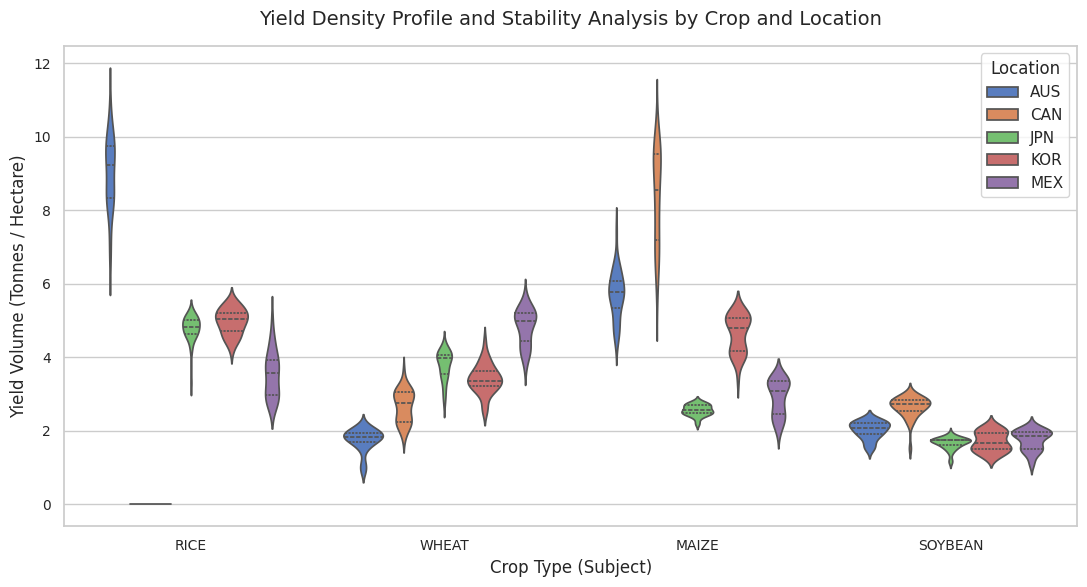

In [10]:
# 3. Visual Narrative: Violin Distribution & Density Plot representing yield stability/risk
plt.figure(figsize=(11, 6))
sns.violinplot(data=clean_subset_df, x='SUBJECT', y='Value', hue='LOCATION', split=False, inner='quart', palette='muted')
plt.title('Yield Density Profile and Stability Analysis by Crop and Location', pad=15)
plt.xlabel('Crop Type (Subject)')
plt.ylabel('Yield Volume (Tonnes / Hectare)')
plt.legend(title='Location', loc='upper right')
plt.tight_layout()
plt.savefig('yield_density_distribution.png', dpi=300)
plt.show()

# Presentation Slide Outline: Agribusiness Crop Yield Storytelling

This outline matches the generated high-resolution plots to structure a compelling executive presentation for industry stakeholders.

---

### **Slide 1: Title & Context**
*   **Slide Title:** Decoupling Global Agricultural Yields: Strategic Insights & Performance Baselines
*   **Sub-title:** An Analytical Deep-Dive into Crop Yield Performance, Regional Advantages, and Climate-Induced Risk (1990 - 2025)
*   **Visual Elements:** Minimalist corporate background with the Agribusiness Analytics Division branding.
*   **Key Talking Points:**
    *   Introduction to the scope: Analyzing five key global markets (Australia, Canada, Japan, South Korea, Mexico) across four core crop profiles (Rice, Wheat, Maize, Soybean).
    *   Objective: Synthesizing raw historical datasets into actionable strategic decisions for global supply chain routing and food security planning.

---

### **Slide 2: Global Trajectories & Technological Yield Dividends**
*   **Slide Title:** Long-Term Growth: Historical Yield Performance Trajectories
*   **Visual Asset:** `global_yield_trajectories.png` (Line plots faceted by Crop Type)
*   **Key Talking Points:**
    *   Maize and Rice show the most aggressive upward trajectories across the analyzed timeframe, indicating high responses to technological progress, seed genetics, and crop management practices.
    *   Noticeable steady, stable yield gradients in Wheat and Soybean across most regions, representing mature but plateauing technical advances.
    *   Identifying anomalies: Specific years showing sudden dips point to historical regional drought events (e.g., Australian wheat cycles).

---

### **Slide 3: Regional Competitiveness & Specialization**
*   **Slide Title:** Comparative Advantages: Regional Yield Benchmarks
*   **Visual Asset:** `crop_productivity_heatmap.png` (Annotated Correlation/Benchmark Matrix Heatmap)
*   **Key Talking Points:**
    *   **Australia** leads significantly in average Rice yields (over 9 Tonnes/Ha), indicating localized competitive advantage in irrigated basins.
    *   **Canada** holds a prominent advantage in Maize productivity, reflecting optimal temperature/soil synergy for modern intensive hybrids.
    *   Using this productivity index to drive sourcing: Directing procurement teams to establish primary contracts in regions displaying optimized yields, minimizing raw material costs.

---

### **Slide 4: Risk Analysis & Climate Resilience**
*   **Slide Title:** Yield Stability: Assessing Production Risks and Volatility
*   **Visual Asset:** `yield_density_distribution.png` (Split Violin Density Plots)
*   **Key Talking Points:**
    *   Understanding the width of the violins: Wider and longer probability distributions (e.g., Australian and Mexican crops) indicate elevated sensitivity to climate fluctuations and weather extremes.
    *   Narrower distributions (e.g., Japan/South Korea rice profiles) indicate reliable crop protective practices, highly structured crop subsidies, and stable production baselines.
    *   Agribusiness Hedging Strategy: Diversify supply contracts between low-risk (narrow distribution) regions and high-yield, variable-risk (wide distribution) regions.

---

### **Slide 5: Executive Conclusions & Next Steps**
*   **Slide Title:** Strategic Road Map & Predictive Excellence
*   **Visual Elements:** Icon-driven bullet points showcasing the transition from descriptive to predictive modeling (referencing the 97.13% R² Random Forest model).
*   **Key Talking Points:**
    *   **Data-Driven Contracting:** Shift from spot-market purchases to forward-looking contracts using predictive models.
    *   **Diversification Mandate:** Mitigate climate risks identified in the violin density profiles by diversifying regional supply hubs.
    *   **Action Plan:** Integrating real-time weather inputs and fertilizer indices to make our predictive models even more robust.